# Demographic features 

This notebook analyses the sociodemographic features at the LSOA scale. It uses data from the 2021 census via the London Datastore available here: https://data.london.gov.uk/census/ 

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, pearsonr

import matplotlib.pyplot as plt
import geopandas as gpd

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Load the 2021 census data 
The Census 2021 data comes from the London Datastore: https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/ 

In [2]:
df_age_census = pd.read_excel('../data/2021_census/Five year age bands.xlsx', sheet_name='2021')
df_occupation_census = pd.read_excel('../data/2021_census/occupation.xlsx', sheet_name='2021')
df_tenure_census = pd.read_excel('../data/2021_census/tenure - households.xlsx', sheet_name='2021')

In [3]:
df_age_census.head()

,LSOA code,local authority code,local authority name,All usual residents,Aged 4 and under,Aged 5 to 9,Aged 10 to 14,Aged 15 to 19,Aged 20 to 24,Aged 25 to 29,...,Aged 40 to 44,Aged 45 to 49,Aged 50 to 54,Aged 55 to 59,Aged 60 to 64,Aged 65 to 69,Aged 70 to 74,Aged 75 to 79,Aged 80 to 84,Aged 85 and over
0,E01000001,E09000001,City of London,1484,52,35,32,23,91,160,...,114,105,89,74,84,120,101,58,57,36
1,E01000002,E09000001,City of London,1382,34,23,22,30,100,166,...,92,95,122,89,87,74,70,59,43,32
2,E01000003,E09000001,City of London,1617,40,35,33,23,95,187,...,113,111,155,118,111,85,87,50,31,34
3,E01000005,E09000001,City of London,1098,50,44,35,89,118,96,...,62,59,87,84,65,35,26,17,13,13
4,E01032739,E09000001,City of London,1613,18,17,34,24,305,326,...,101,81,104,68,54,31,14,8,7,2


In [4]:
df_occupation_census.head()

,local authority code,local authority name,LSOA code,All usual residents aged 16 and over in employment,"1. Managers, directors and senior officials",2. Professional occupations,3. Associate professional and technical occupations,4. Adminis-trative and secretarial occupations,5. Skilled trades occupations,"6. Caring, leisure and other service occupations",7. Sales and customer service occupations,"8. Process, plant and machine operatives",9. Elementary occupations
0,E09000001,City of London,E01000001,868,194,406,184,39,5,19,11,6,4
1,E09000001,City of London,E01000002,875,218,414,187,35,3,5,3,3,7
2,E09000001,City of London,E01000003,1002,191,388,217,72,28,27,26,11,42
3,E09000001,City of London,E01000005,494,52,129,61,43,21,52,34,16,86
4,E09000001,City of London,E01032739,1184,253,540,216,48,23,37,40,6,21


In [5]:
df_tenure_census.head()

,LSOA code,local authority code,local authority name,All Households,Owned outright,Owned with a mortgage or loan,Shared ownership,Rented from Local Authority,Other social rented,Private landlord or letting agency,Other private rented,Rent free
0,E01000001,E09000001,City of London,843,338,144,3,17,4,283,53,1
1,E01000002,E09000001,City of London,825,283,149,2,23,6,324,38,0
2,E01000003,E09000001,City of London,1015,232,145,0,249,52,293,42,2
3,E01000005,E09000001,City of London,482,19,22,1,148,186,91,15,0
4,E01032739,E09000001,City of London,882,118,98,3,3,8,555,97,0


In [6]:
# add column >50 to df_age_census
df_age_census['age_50_plus'] = df_age_census[['Aged 50 to 54', 'Aged 55 to 59', 'Aged 60 to 64', 'Aged 65 to 69', 'Aged 70 to 74', 'Aged 75 to 79', 'Aged 80 to 84', 'Aged 85 and over']].sum(axis=1)
df_age_census['percent_age_50_plus'] = df_age_census['age_50_plus'] / df_age_census['All usual residents'] * 100

# add column summing 1,2,3 occupations to df_occupation_census
df_occupation_census['occupation_1_2_3'] = df_occupation_census[['1. Managers, directors and senior officials', '2. Professional occupations', '3. Associate professional and technical occupations']].sum(axis=1)
df_occupation_census['percent_occupation_1_2_3'] = df_occupation_census['occupation_1_2_3'] / df_occupation_census['All usual residents aged 16 and over in employment'] * 100

# add column owned outright + owned with mortgage to df_tenure_census
df_tenure_census['owned_total'] = df_tenure_census[['Owned outright', 'Owned with a mortgage or loan']].sum(axis=1)
df_tenure_census['percent_owned_total'] = df_tenure_census['owned_total'] / df_tenure_census['All Households'] * 100

In [7]:
# merge df_age_census with df_occupation_census and df_tenure_census on LSOA code
df_census = pd.merge(df_age_census[['LSOA code', 'percent_age_50_plus']], df_occupation_census[['LSOA code', 'percent_occupation_1_2_3']], on='LSOA code', how='left')
df_census = pd.merge(df_census, df_tenure_census[['LSOA code', 'percent_owned_total']], on='LSOA code', how='left')

In [8]:
df_census.head()

,LSOA code,percent_age_50_plus,percent_occupation_1_2_3,percent_owned_total
0,E01000001,41.711590,90.322581,57.176750
1,E01000002,41.678726,93.600000,52.363636
2,E01000003,41.496599,79.441118,37.142857
3,E01000005,30.965392,48.987854,8.506224
4,E01032739,17.854929,85.219595,24.489796


### Load the LSOA boundaries for London 
The LSOA boundaries come from ONS geoportal: https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2021-boundaries-ew-bsc-v4-2/about

In [9]:
df_lsoa_boundaries = gpd.read_file('../data/london_geos/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_-4299016806856585929.geojson')
df_lsoa_boundaries = df_lsoa_boundaries[df_lsoa_boundaries['LSOA21CD'].isin(df_age_census['LSOA code'])]

In [10]:
df_lsoa_boundaries.head()

,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.09474 51.5206, -0.09546 51.51544,..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.0881 51.51941, -0.09546 51.51544,..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.09453 51.52205, -0.09274 51.52139..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.07589 51.5159, -0.07394 51.51445,..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.09328 51.53787, 0.09363 51.53767, ..."


### Load the comments dataframe 
Read the remote database of free-text comments 
TO DO: Check why for some reason the column here 'lsoa_code' doesn't correlate with London LSOAs in df_lsoa_boundaries. Instead re-calculate the lsoa_codes for each comment by locating their lat and lon co-ordinates. 

In [11]:
cs_df = cs.read_all()

In [12]:
cs_df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557


In [13]:
# get lsoa codes for comments using 'lat' and 'lon' to locate within df_lsoa_boundaries

cs_df['lsoa_code_updated'] = None

for lat, lon in zip(cs_df['lat'], cs_df['lon']):
    point = gpd.points_from_xy([lon], [lat])
    point_gdf = gpd.GeoDataFrame(geometry=point, crs='EPSG:4326')
    point_gdf = point_gdf.to_crs(df_lsoa_boundaries.crs)
    joined = gpd.sjoin(point_gdf, df_lsoa_boundaries, how='left')
    lsoa_code = joined.iloc[0]['LSOA21CD']
    cs_df.loc[(cs_df['lat'] == lat) & (cs_df['lon'] == lon), 'lsoa_code_updated'] = lsoa_code

In [14]:
cs_df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,lsoa_code_updated
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,E09000003,-0.244143,E01000279
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,E09000009,-0.232367,E01001228
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",E09000009,-0.167873,E01001253
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,E09000003,-0.315872,E01000141
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,E09000003,-0.229557,E01000292


In [15]:
# merge cs_df with df_age_census on lsoa_code to get percent_age_50_plus for each comment
cs_df = pd.merge(cs_df, df_census, left_on='lsoa_code_updated', right_on='LSOA code', how='left')
cs_df.drop(columns=['LSOA code', 'lsoa_code'], inplace=True)

In [16]:
cs_df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,sentiment_score,lsoa_code_updated,percent_age_50_plus,percent_occupation_1_2_3,percent_owned_total
0,88439,Barnet,23/4221/FUL_13,23/4221/FUL,45 Pine Grove Totteridge London N20 8LA,Objects,2023-11-08,I object to the proposed planning application ...,2025-04-10,51.632395,-0.194255,I object to the proposed planning application ...,-0.244143,E01000279,50.036576,77.317881,85.854617
1,94013,Ealing,215737FUL_2,215737FUL,53 Gordon Road Ealing London W5 2AL W5 2AL,Objects,2021-10-30,I am writing as Chair of the GRASS (Gordon Roa...,2025-04-11,51.514611,-0.311787,I am writing as Chair of the GRASS ( and Surro...,-0.232367,E01001228,26.663032,65.367582,37.605804
2,106710,Ealing,230760FUL_6,230760FUL,19 Studley Grange Road Hanwell W7 2Lu W7 2Lu,Objects,2023-09-24,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",2025-05-01,51.503314,-0.336865,"Dear Sir/Madam,\n\nAs a direct neighbour (on t...",-0.167873,E01001253,26.829268,58.630137,57.272727
3,88908,Brent,20/0115_42,20/0115,"34 Gratton Terrace, London, NW2 6QE",Objects,2020-06-11,11/06/2020 - Further objection comment receive...,2025-04-10,51.560030,-0.218620,11/06/2020 - Further objection comment receive...,-0.315872,E01000141,27.218935,42.928287,27.742749
4,76007,Barnet,22/4044/FUL_2,22/4044/FUL,8 May's Lane Barnet EN5 2EE,Objects,2022-09-05,CONTINUED\nArticle 8 of the Human Rights Act s...,2025-04-08,51.645724,-0.203315,CONTINUED\nArticle 8 of the Human Rights Act s...,-0.229557,E01000292,43.329016,66.812865,69.724771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30388,73094,Barnet,23/4779/FUL_3,23/4779/FUL,106 torrington park london n129pj,Objects,2023-12-08,Council must Protecting Barnet's character and...,2025-04-04,51.507446,-0.127765,Council must Protecting Barnet's character and...,-0.352118,E01004736,26.039536,80.389908,32.989691
30389,79288,Barnet,21/5247/FUL_21,21/5247/FUL,22 Lambert Road Finchley N12 9ES,Objects,2021-11-01,The plans submitted for this development are c...,2025-04-08,51.613109,-0.173991,The plans submitted for this development are c...,-0.318891,E01000323,29.598309,50.286182,34.257426
30390,73102,Barnet,23/5391/FUL_4,23/5391/FUL,8 Shamrock Way London N14 5RY,Objects,2024-02-19,Dear Sir/Madam\nReference Planning Requests: 2...,2025-04-04,51.633100,-0.140270,Dear Sir/Madam\nReference Planning Requests: 2...,-0.211599,E01000120,42.084168,64.964539,85.542169
30391,87675,Ealing,221304FUL_1,221304FUL,62 Mill Hill Road London W3 8JH W3 8JH,Objects,2022-07-30,I have read comments in 'support' of this exte...,2025-04-10,51.506210,-0.275670,I have read comments in 'support' of this exte...,-0.225221,E01001351,30.761421,54.652302,34.740651


In [17]:
# check statistical difference in means between lsoa's with comments and all london lsoa's

lsoa_with_comment = cs_df['lsoa_code_updated'].unique().tolist()

print("\nStatistical comparison of means between LSOA's with comments and all London LSOA's:\n")

# perform t-test for each feature
for feature in ['percent_age_50_plus', 'percent_occupation_1_2_3', 'percent_owned_total']:
    t_stat, p_val = ttest_ind(
        df_census[feature],
        df_census[df_census['LSOA code'].isin(lsoa_with_comment)][feature]
    )
    print("London mean for {}: {:.2f}".format(feature, df_census[feature].mean()))
    print("LSOA's with comments mean for {}: {:.2f}".format(feature, df_census[df_census['LSOA code'].isin(lsoa_with_comment)][feature].mean()))
    print(f"T-test for {feature}: t-statistic = {t_stat}, p-value = {p_val}")
    if p_val < 0.05:
        print(f"Statistically significant difference in means for {feature} (p < 0.05)\n ")
    else:
        print(f"No statistically significant difference in means for {feature} (p >= 0.05)\n")



Statistical comparison of means between LSOA's with comments and all London LSOA's:

London mean for percent_age_50_plus: 29.21
LSOA's with comments mean for percent_age_50_plus: 29.60
T-test for percent_age_50_plus: t-statistic = -1.4935795881691425, p-value = 0.1353366385543602
No statistically significant difference in means for percent_age_50_plus (p >= 0.05)

London mean for percent_occupation_1_2_3: 55.00
LSOA's with comments mean for percent_occupation_1_2_3: 53.73
T-test for percent_occupation_1_2_3: t-statistic = 2.4393781835310544, p-value = 0.014740526922871497
Statistically significant difference in means for percent_occupation_1_2_3 (p < 0.05)
 
London mean for percent_owned_total: 46.71
LSOA's with comments mean for percent_owned_total: 46.14
T-test for percent_owned_total: t-statistic = 0.8411293276518913, p-value = 0.40030806226579585
No statistically significant difference in means for percent_owned_total (p >= 0.05)



### Scatter plots of the number of comments (per LSOA) versus key socioeconomic factors (per LSOA)
- percent_age_50_plus vs count of comments
- percent_occupation_1_2_3 vs count of comments 
- percent_owned_total vs count of comments

Repeat excluding planning applications with comment_count = 1. Justify this exclusion based on the predominance of applications with 1 comment - essentially a normal amount of comments. 
- percent_age_50_plus vs count of comments with comment count = 1 removed
- percent_occupation_1_2_3 vs count of comments with comment count = 1 removed
- percent_owned_total vs count of comments with comment count = 1 removed

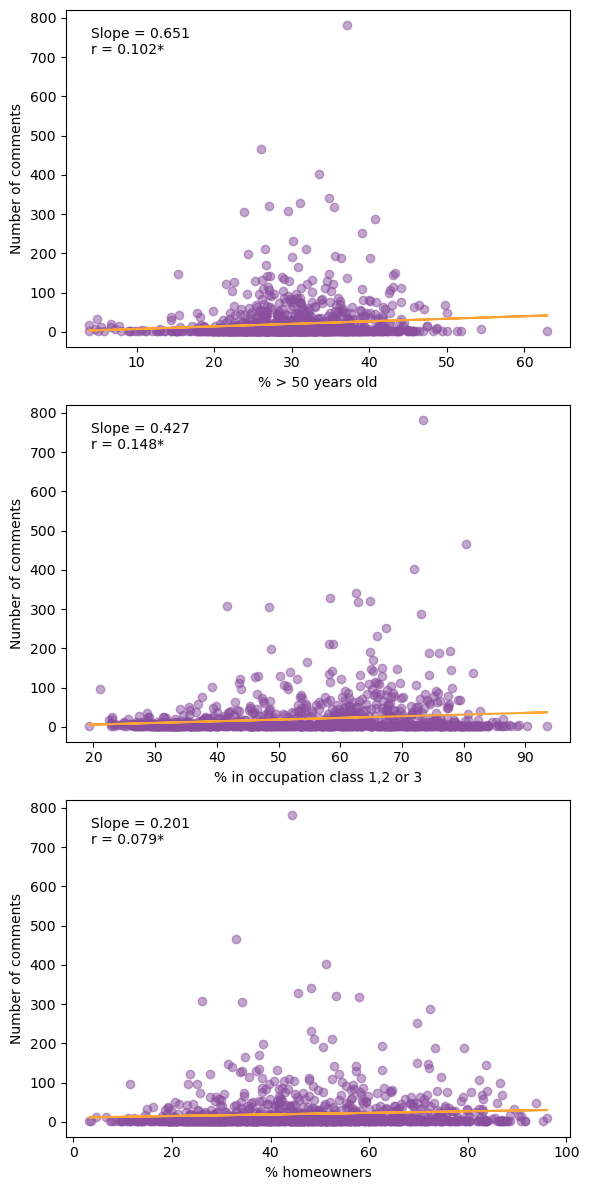

In [29]:
# Variables to plot
socio_vars = [
    'percent_age_50_plus',
    'percent_occupation_1_2_3',
    'percent_owned_total'
]

# Aggregate to LSOA level
grouped = (
    cs_df
    .groupby('lsoa_code_updated')
    .agg({
        'comment_id': 'count',
        'percent_age_50_plus': 'mean',
        'percent_occupation_1_2_3': 'mean',
        'percent_owned_total': 'mean'
    })
    .reset_index()
)

x_labels = [
    '% > 50 years old',
    '% in occupation class 1,2 or 3',
    '% homeowners'
]

# Filtered version (exclude LSOAs with only 1 comment)
grouped_filtered = grouped[grouped['comment_id'] > 1]

# Create 3 rows x 1 column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 12), sharey='row')

for i, var in enumerate(socio_vars):

    ax = axes[i]
    ax.scatter(grouped[var], grouped['comment_id'], alpha=0.5, color="#894e9e")
    
    # Line of best fit
    m, b = np.polyfit(grouped[var], grouped['comment_id'], 1)
    ax.plot(grouped[var], m * grouped[var] + b, color="#fba337")

    ax.set_xlabel(x_labels[i])
    ax.set_ylabel('Number of comments')
    # ax.set_title(f'{var.replace("_", " ").title()} (All LSOAs)')

    r, p = pearsonr(grouped[var], grouped['comment_id'])
    sig = '*' if p < 0.05 else ''

    ax.text(
        0.05, 0.95,
        f"Slope = {m:.3f}\n"
        f"r = {r:.3f}{sig}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

plt.tight_layout()
plt.savefig('../results/figures/demographic_features_vs_comment_count.png', dpi=600)
plt.show()